# What determines the Breast Cancer is Maligment or Benign?
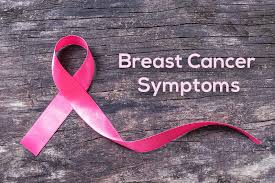

**OVERVIEW**

In this application, I will explore a dataset from Kaggle. The dataset contained information on 569 patient of Wisconsin (Diagnostic). My goal is to understand what factors make a cancer Malignment or Benign.

### CRISP-DM Framework

<center>
    <img src = crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.

### Business Understanding

From a business perspective, I am tasked with identifying key drivers for detecting Brest Cancer.  In the CRISP-DM overview, I am asked to convert this business framing to a data problem definition. Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Load the data and analyze the data frame

In [110]:
!pip install ucimlrepo

In [112]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score
import seaborn as sns
import numpy as np

#### Change the target `M` to True and `B` to False

In [117]:
y['Diagnosis'] = y['Diagnosis'].replace({'M': True, 'B': False})

C:\Users\Ansuman\AppData\Local\Temp\ipykernel_33328\1115811751.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y['Diagnosis'] = y['Diagnosis'].replace({'M': True, 'B': False})
C:\Users\Ansuman\AppData\Local\Temp\ipykernel_33328\1115811751.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Diagnosis'] = y['Diagnosis'].replace({'M': True, 'B': False})


#### Encode the target label

In [120]:
y.Diagnosis.unique()
y = y['Diagnosis']
le = LabelEncoder()
y = le.fit_transform(y)

#### Split the data to training and test set

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Create the transformer

In [126]:
num = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

trxfer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num),
    ]
)

#### Build a simple Regression Model

In [129]:
simpleLRPipeline = Pipeline([
        ('preprocessor', trxfer),
        ('lr', LogisticRegression())
    ])

simpleLRPipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['radius1', 'texture1',
                                                   'perimeter1', 'area1',
                                                   'smoothness1',
                                                   'compactness1', 'concavity1',
                                                   'concave_points1',
                                                   'symmetry1',
                                                   'fractal_dimension1',
                                                   'radius2', 'texture2',
                                                   'perimeter2', 'area2',
                                                   'smoothness2',
                                                   'compactness2', 'concavity2',
                                                   'concave_points2',
                                                   'symmetry2',
                                                   'fractal_dimension2',
                                                   'radius3', 'texture3',
                                                   'perimeter3', 'area3',
                                                   'smoothness3',
                                                   'compactness3', 'concavity3',
                                                   'concave_points3',
                                                   'symmetry3',
                                                   'fractal_dimension3'])])),
                ('lr', LogisticRegression())])

#### Calculate the accurary, precision and recall for the simple model

In [132]:
preds = simpleLRPipeline.predict(X_test)
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
print(f'Accuracy: {accuracy: .2f}\nPrecision: {precision: .2f}\nRecall: {recall: .2f}')

Accuracy:  0.97
Precision:  0.98
Recall:  0.95


#### Create multiple model without hyper-parameter, find the accurary, precision and recall of model. Display Confusion Matrix of the model on test set.

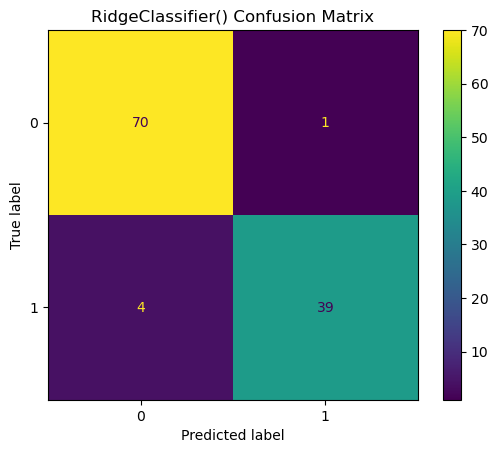

ridge 0.0741581916809082 0.967032967032967 0.956140350877193 1.0 0.975 0.9069767441860465 0.9069767441860465


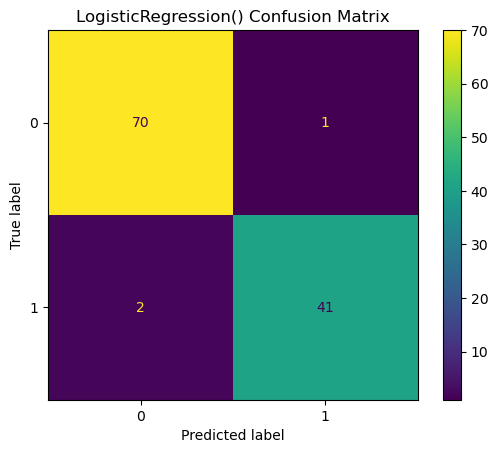

logistic 0.08241105079650879 0.9868131868131869 0.9736842105263158 0.9880239520958084 0.9761904761904762 0.9534883720930233 0.9534883720930233


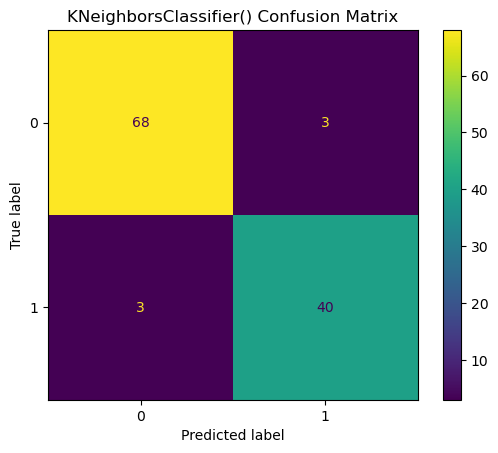

knn 0.051192522048950195 0.9802197802197802 0.9473684210526315 1.0 0.9302325581395349 0.9302325581395349 0.9302325581395349


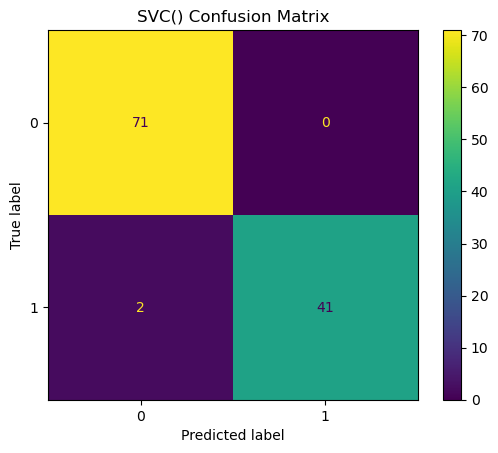

svc 0.07340788841247559 0.989010989010989 0.9824561403508771 1.0 1.0 0.9534883720930233 0.9534883720930233


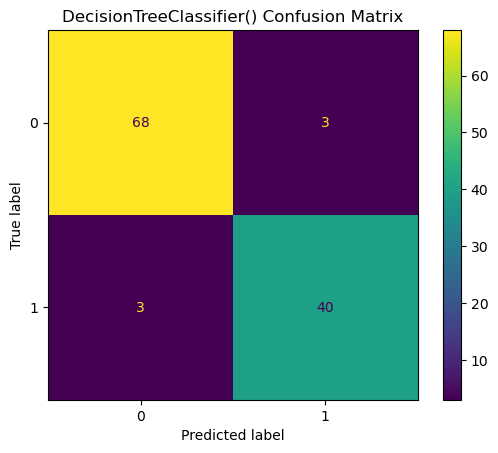

decisiontree 0.09680891036987305 1.0 0.9473684210526315 1.0 0.9302325581395349 0.9302325581395349 0.9302325581395349


In [135]:
defaultModels = {
    'ridge': (RidgeClassifier()),
    'logistic': (LogisticRegression()),
    'knn': (KNeighborsClassifier()),
    'svc': (SVC()),
    'decisiontree': (DecisionTreeClassifier())
}

defaultResults = []

for name, (model) in defaultModels.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', trxfer),
        (name, model)
    ])
    # Fit the model and time it
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = (time.time() - start_time)
    
    y_train_predictions = pipeline.predict(X_train)
    y_test_predictions = pipeline.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_predictions)
    test_accuracy = accuracy_score(y_test, y_test_predictions)
    train_precision = precision_score(y_train, y_train_predictions)
    test_precision = precision_score(y_test, y_test_predictions)
    train_recall = recall_score(y_test, y_test_predictions)
    test_recall = recall_score(y_test, y_test_predictions)

    cm = confusion_matrix(y_test, y_test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    disp.ax_.set_title(str(model) + " Confusion Matrix")
    plt.show()

    print (name, fit_time, train_accuracy, test_accuracy, train_precision, test_precision, train_recall, test_recall)
    # Append the results
    defaultResults.append([name, fit_time, train_accuracy, test_accuracy, train_precision, test_precision, train_recall, test_recall])


In [139]:
defaultResults_df = pd.DataFrame(defaultResults, columns=['model', 'fit time','train accuracy', 'test accuracy', 'train precision', 'test precision', 'train recall', 'test recall'])
defaultResults_df.set_index('model', inplace=True)
defaultResults_df

,fit time,train accuracy,test accuracy,train precision,test precision,train recall,test recall
model,,,,,,,
ridge,0.074158,0.967033,0.956140,1.000000,0.975000,0.906977,0.906977
logistic,0.082411,0.986813,0.973684,0.988024,0.976190,0.953488,0.953488
knn,0.051193,0.980220,0.947368,1.000000,0.930233,0.930233,0.930233
svc,0.073408,0.989011,0.982456,1.000000,1.000000,0.953488,0.953488
decisiontree,0.096809,1.000000,0.947368,1.000000,0.930233,0.930233,0.930233


#### Create multiple model with hyper-parameter, find the accurary, precision and recall of model. Display Confusion Matrix of the model on test set.

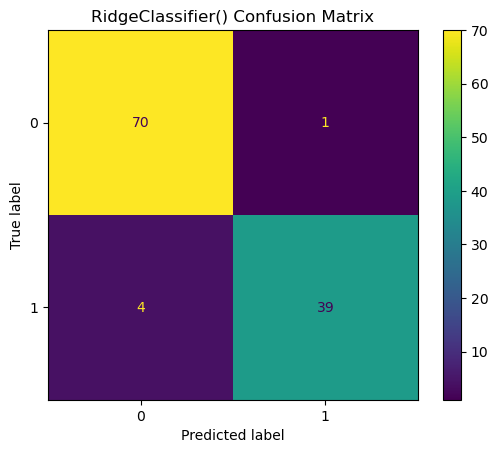

ridge 0.3193946361541748 0.967032967032967 0.956140350877193 {'ridge__alpha': 1.0} 1.0 0.975 0.9302325581395349 0.9069767441860465


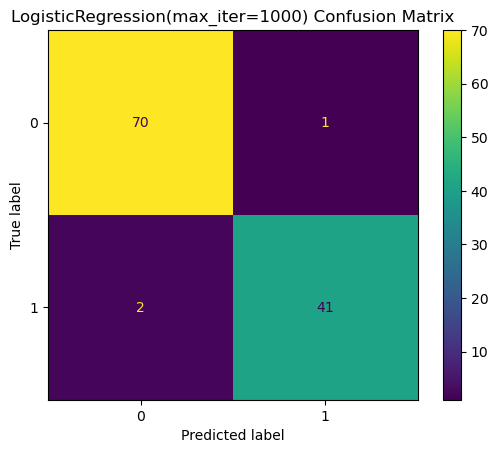

logistic 0.060157942771911624 0.9868131868131869 0.9736842105263158 {'logistic__C': 1.0} 0.9880239520958084 0.9761904761904762 0.9302325581395349 0.9534883720930233


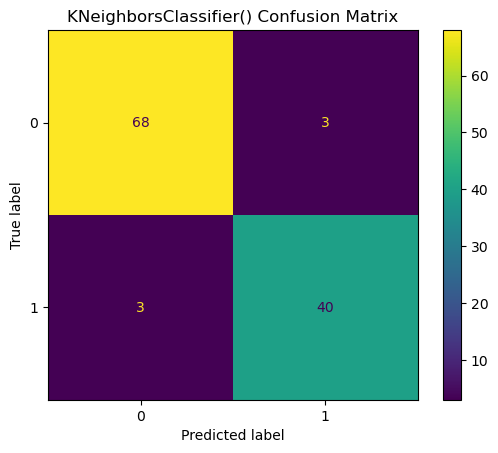

knn 0.26907231889922045 0.9802197802197802 0.9473684210526315 {'knn__n_neighbors': 5} 1.0 0.9302325581395349 0.9302325581395349 0.9302325581395349


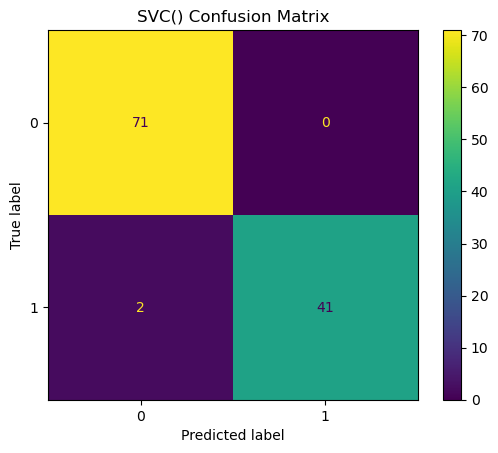

svc 0.08033531904220581 0.9824175824175824 0.9824561403508771 {'svc__C': 0.1, 'svc__kernel': 'linear'} 0.9878787878787879 1.0 0.9302325581395349 0.9534883720930233


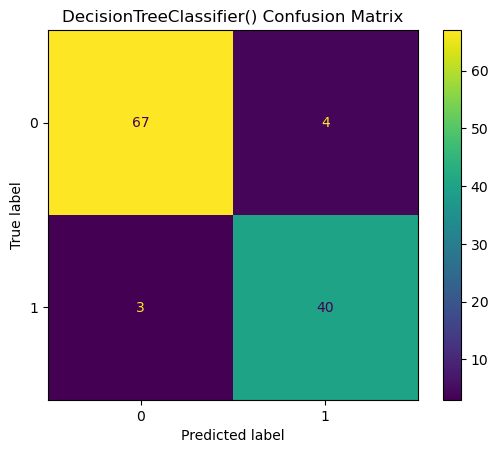

decisiontree 0.15590815544128417 1.0 0.9385964912280702 {'decisiontree__max_depth': 10} 1.0 0.9090909090909091 0.9302325581395349 0.9302325581395349


In [148]:
ridge_hyper = {'ridge__alpha': 10**np.linspace(-5,4,10)}
logistic_hyper = {'logistic__C': 10**np.linspace(-5,4,10)}
knn_hyper = {'knn__n_neighbors': list(range(1, 30, 1))}
decisiontree_hyper = {'decisiontree__max_depth': [5, 10, 15,20,25,30,35,40,45,50]}

models = {
    'ridge': (RidgeClassifier(), ridge_hyper),
    'logistic': (LogisticRegression(max_iter=1000), logistic_hyper),
    'knn': (KNeighborsClassifier(), knn_hyper),
    'svc': (SVC(), {'svc__C': 10**np.linspace(-5,4,10), 'svc__kernel': ['linear', 'rbf']}),
    'decisiontree': (DecisionTreeClassifier(), decisiontree_hyper )
}

results = []
for name, (model, params) in models.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', trxfer),
        (name, model)
    ])
    # Perform grid search
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1)

    # Fit the model and time it
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])

    # Get the best estimator
    best_model = grid_search.best_estimator_

    # Evaluate on training and test sets
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)
    
    predictions = best_model.predict(X_test)

    y_train_predictions = best_model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_predictions)
    test_accuracy = accuracy_score(y_test, predictions)
    train_precision = precision_score(y_train, y_train_predictions)
    test_precision = precision_score(y_test, predictions)
    train_recall = recall_score(y_test, y_test_predictions)
    test_recall = recall_score(y_test, predictions)

    
    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    disp.ax_.set_title(str(model) + " Confusion Matrix")
    plt.show()
    print (name, fit_time, train_score, test_score, grid_search.best_params_, train_precision,test_precision, train_recall,test_recall )    
    # Append the results
    results.append([name, fit_time, train_score, test_score, train_precision, test_precision, train_recall,test_recall, grid_search.best_params_])


In [150]:
results_df = pd.DataFrame(results, columns=['model', 'average fit time', 'train score', 'test score',' train precision', 'test precision','train recall','test recall', 'hyper'])
results_df.set_index('model', inplace=True)
results_df

,average fit time,train score,test score,train precision,test precision,train recall,test recall,hyper
model,,,,,,,,
ridge,0.319395,0.967033,0.956140,1.000000,0.975000,0.930233,0.906977,{'ridge__alpha': 1.0}
logistic,0.060158,0.986813,0.973684,0.988024,0.976190,0.930233,0.953488,{'logistic__C': 1.0}
knn,0.269072,0.980220,0.947368,1.000000,0.930233,0.930233,0.930233,{'knn__n_neighbors': 5}
svc,0.080335,0.982418,0.982456,0.987879,1.000000,0.930233,0.953488,"{'svc__C': 0.1, 'svc__kernel': 'linear'}"
decisiontree,0.155908,1.000000,0.938596,1.000000,0.909091,0.930233,0.930233,{'decisiontree__max_depth': 10}
